#Text_emotion_classification

#1-Load Data

In [1]:
!pip install datasets

In [2]:
import pandas as pd
train = pd.read_parquet("train-00000-of-00001.parquet")
valid = pd.read_parquet("validation-00000-of-00001.parquet")
test = pd.read_parquet("test-00000-of-00001.parquet")
print(train.head())

                                                text  label
0                            i didnt feel humiliated      0
1  i can go from feeling so hopeless to so damned...      0
2   im grabbing a minute to post i feel greedy wrong      3
3  i am ever feeling nostalgic about the fireplac...      2
4                               i am feeling grouchy      3


In [4]:
from datasets import load_dataset
dataset = load_dataset('parquet', data_files={'train': 'train-00000-of-00001.parquet',
                                             'validation': 'validation-00000-of-00001.parquet',
                                             'test': 'test-00000-of-00001.parquet'})
print(dataset)

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [5]:
print(dataset["train"][0])

{'text': 'i didnt feel humiliated', 'label': 0}


In [6]:
import pandas as pd
df = dataset["train"].to_pandas()
df.to_csv("emotion_train.csv", index=False)

#2-Load Libraries

In [7]:
import numpy as np
import pandas as pd
import pickle
import nltk
import re
import string
from sklearn.preprocessing import LabelEncoder
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [8]:
# Download required NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [9]:
import pandas as pd
df = pd.read_csv(
    "emotion_train.csv",
    sep=","
)
df["length"] = df["text"].apply(len)

In [10]:
# Label mapping
LABEL_NAMES = dataset["train"].features["label"].names
NUM_LABELS  = len(LABEL_NAMES)
id2label    = {i: l for i, l in enumerate(LABEL_NAMES)}
label2id    = {l: i for i, l in enumerate(LABEL_NAMES)}
print("Labels:", LABEL_NAMES)

Labels: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


In [11]:
# Preview a few examples
df_train = dataset["train"].to_pandas()
df_train["emotion"] = df_train["label"].map(id2label)
df_train.head(10)

,text,label,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger
5,ive been feeling a little burdened lately wasn...,0,sadness
6,ive been taking or milligrams or times recomme...,5,surprise
7,i feel as confused about life as a teenager or...,4,fear
8,i have been with petronas for years i feel tha...,1,joy
9,i feel romantic too,2,love


In [12]:
df_train.head()

,text,label,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


In [13]:
df_train.tail()

,text,label,emotion
15995,i just had a very brief time in the beanbag an...,0,sadness
15996,i am now turning and i feel pathetic that i am...,0,sadness
15997,i feel strong and good overall,1,joy
15998,i feel like this was such a rude comment and i...,3,anger
15999,i know a lot but i feel so stupid because i ca...,0,sadness


In [14]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   text     16000 non-null  object
 1   label    16000 non-null  int64 
 2   emotion  16000 non-null  object
dtypes: int64(1), object(2)
memory usage: 375.1+ KB


In [15]:
df_train.shape

(16000, 3)

In [16]:
df_train.isnull().sum()

,0
text,0
label,0
emotion,0


In [17]:
df_train.duplicated().sum()


np.int64(1)

In [18]:
df_train.drop_duplicates(inplace=True)

In [19]:
df_train.duplicated().sum()

np.int64(0)

In [ ]:
df_train['label'].value_counts()

,count
label,
1,5361
0,4666
3,2159
4,1937
2,1304
5,572


In [20]:
df_train["length"] = df_train["text"].apply(len)
df_train["length"].describe()

,length
count,15999.000000
mean,96.847990
std,55.906021
min,7.000000
25%,53.000000
50%,86.000000
75%,129.000000
max,300.000000


#3-Exploratory Data Analysis (ُEDA)

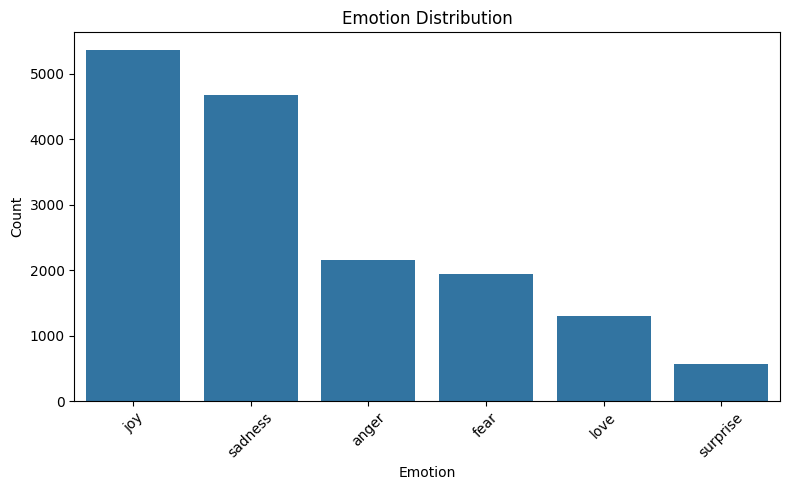

In [21]:
# General label mapping
plt.figure(figsize=(8, 5))
sns.countplot(
    x='emotion',
    data=df_train,
    order=df_train['emotion'].value_counts().index
)
plt.title('Emotion Distribution')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

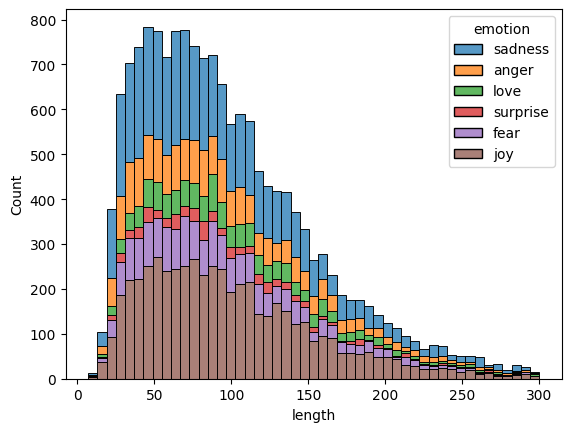

In [22]:
# Add 'length' column to df_train
df_train['length'] = df_train['text'].apply(len)
# Plot histogram
sns.histplot(
    data=df_train,
    x='length',
    hue='emotion',
    multiple='stack'
)
plt.show()

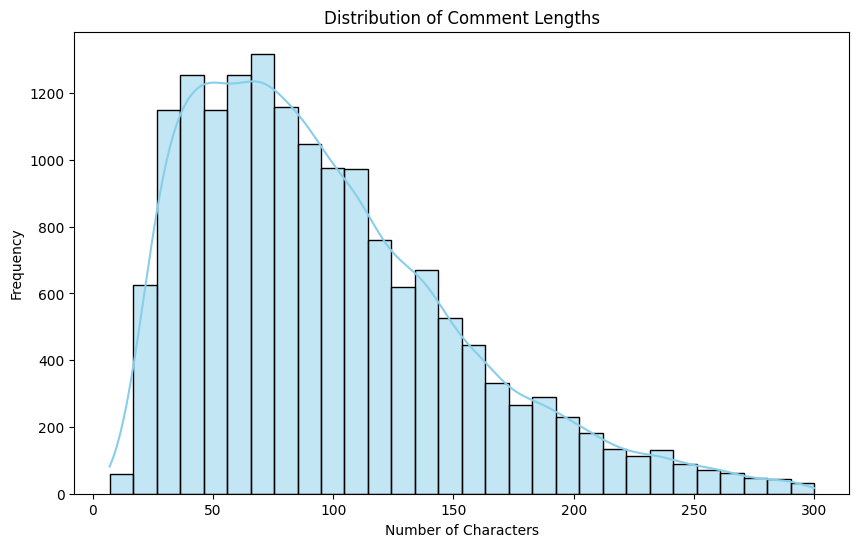

In [23]:
plt.figure(figsize=(10, 6))
sns.histplot(df['length'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Comment Lengths')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.show()

Text Length Analysis

In [24]:
#Average Length
print('Average Length : ', df_train['length'].mean())

Average Length :  96.84799049940621


In [25]:
#maximum Lenght
print('Maximum Length : ', df_train['length'].max())

Maximum Length :  300


In [26]:
# Minimum Lenght
print('Minimum Length : ', df_train['length'].min())


Minimum Length :  7


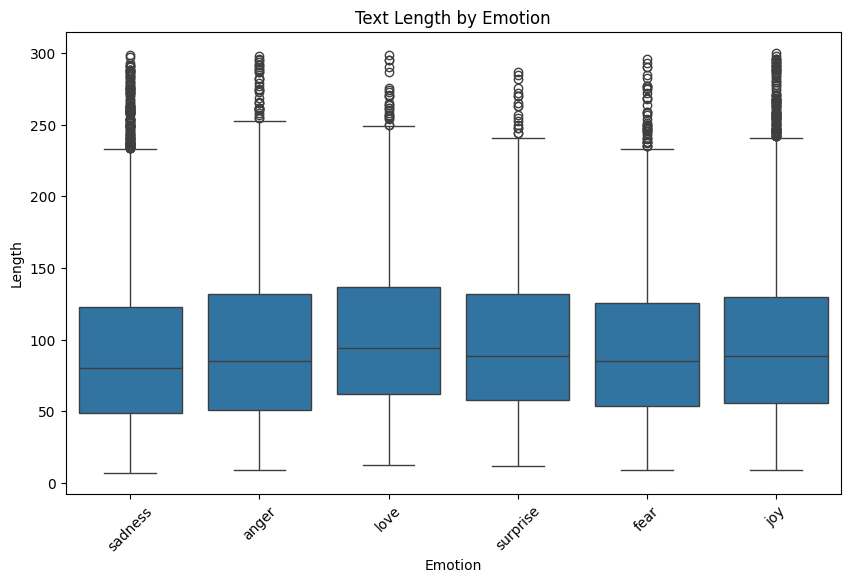

In [27]:
#Text Length Per Emotion
plt.figure(figsize=(10,6))
sns.boxplot(
    x='emotion',
    y='length',
    data=df_train
)

plt.title('Text Length by Emotion')
plt.xlabel('Emotion')
plt.ylabel('Length')

plt.xticks(rotation=45)

plt.show()

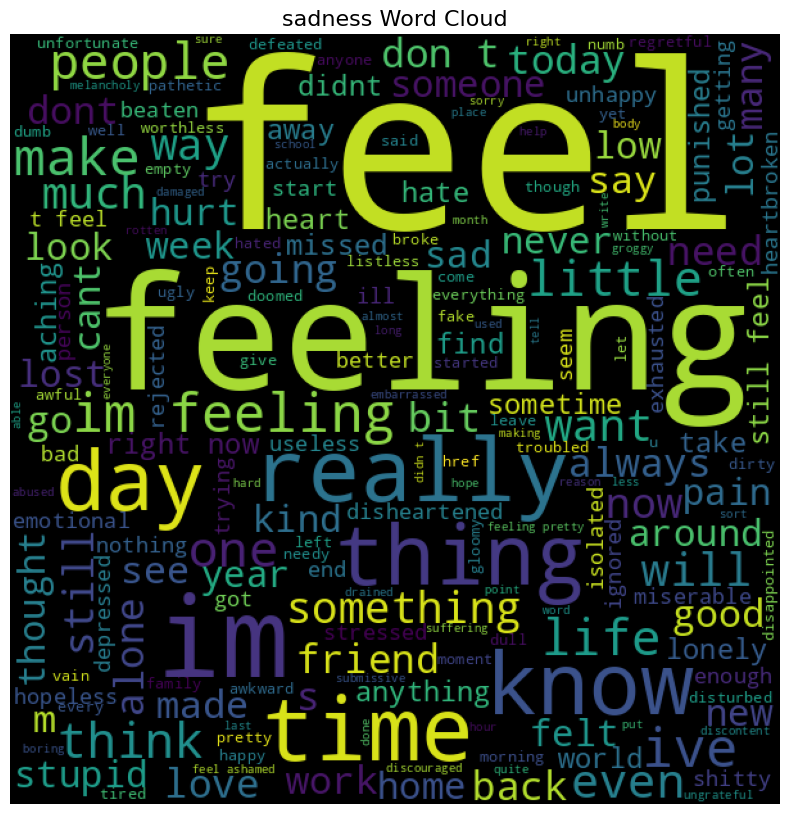

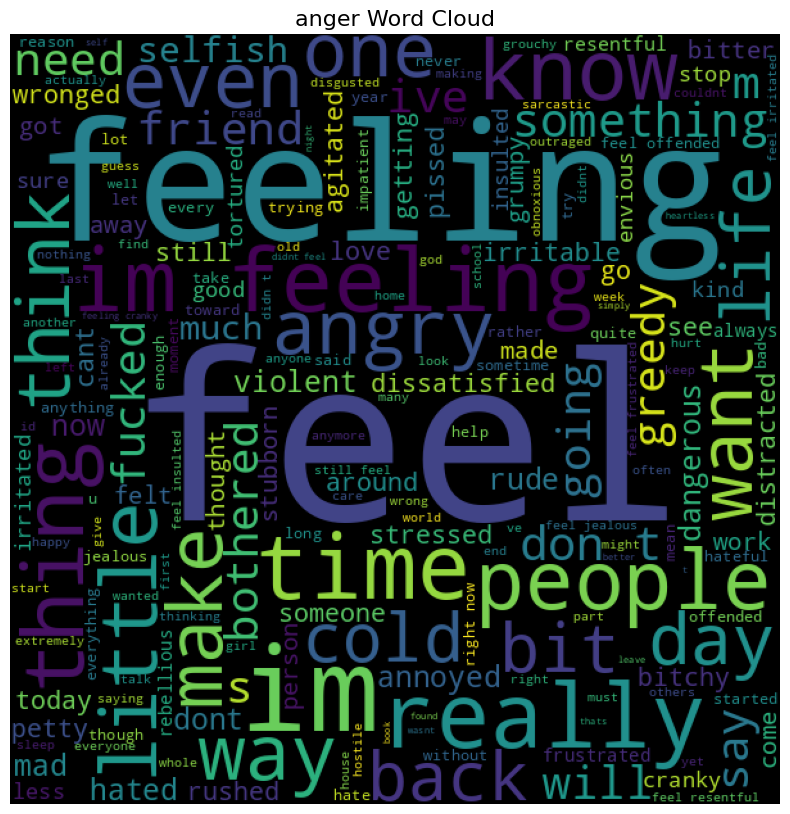

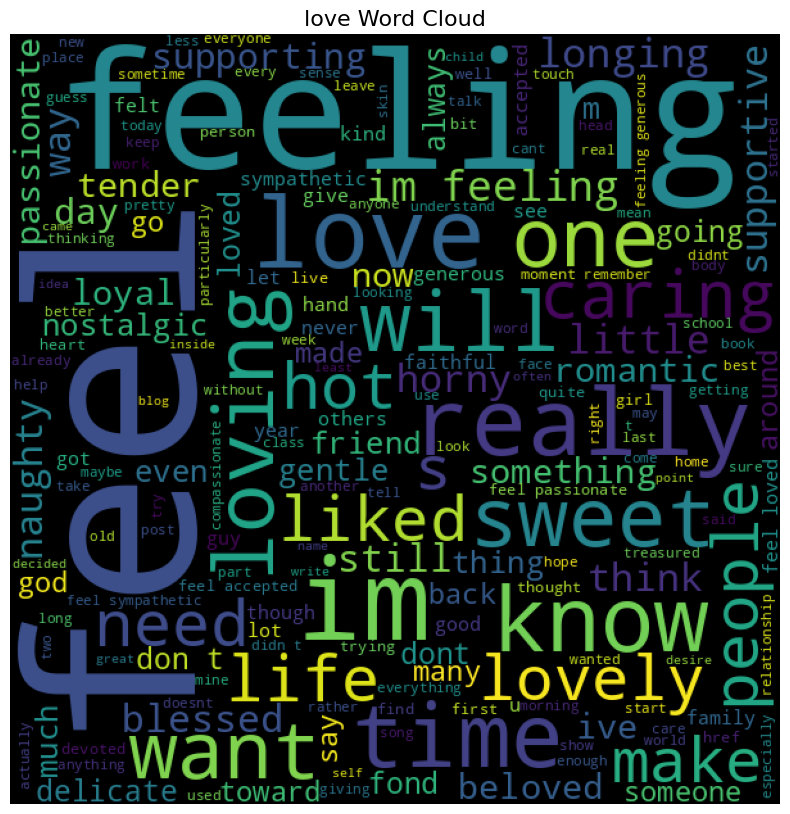

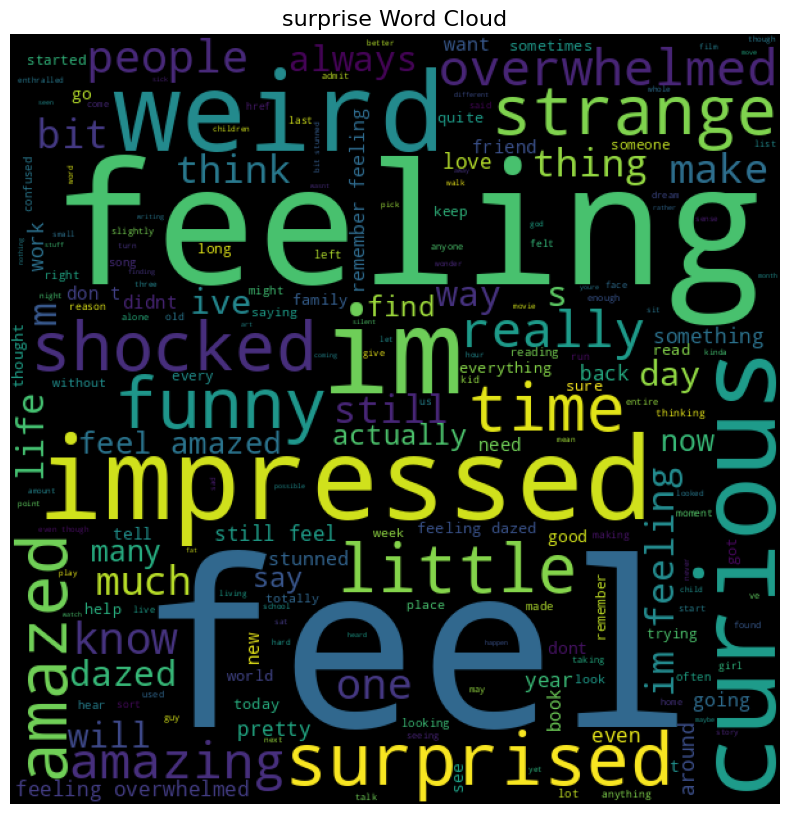

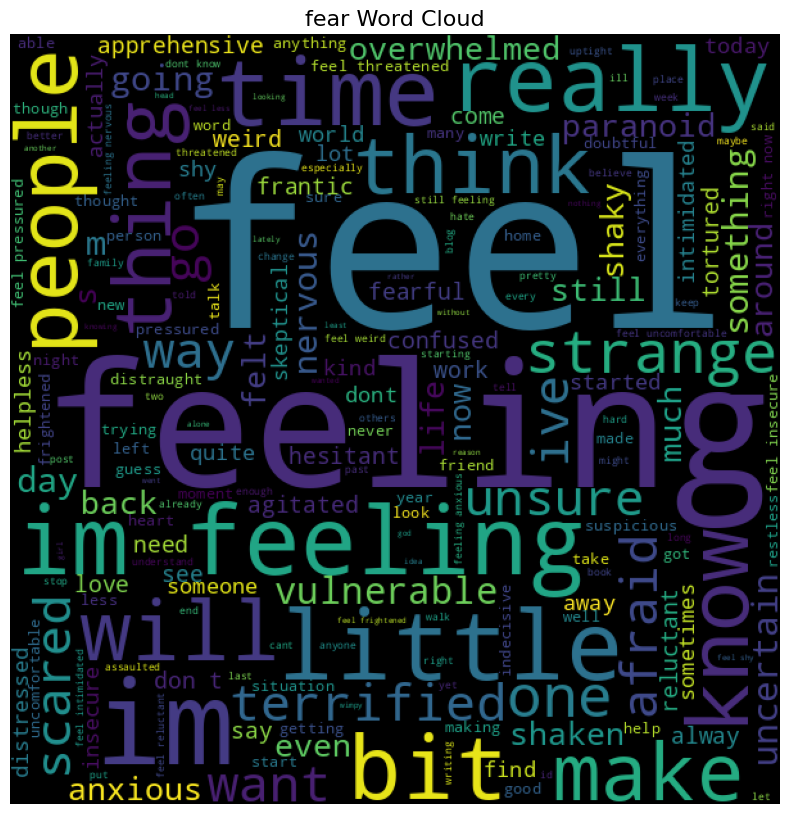

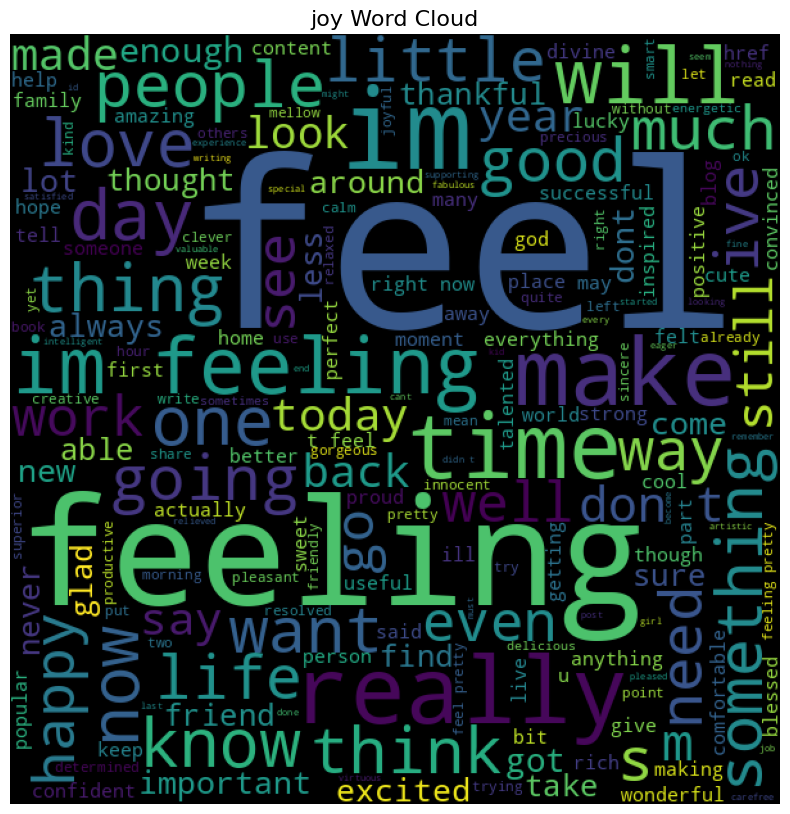

In [28]:
# Words cloud for each emotions
def words_cloud(wordcloud_obj, emotion_name):
    plt.figure(figsize=(10, 10))
    plt.title(emotion_name + ' Word Cloud', size = 16)
    plt.imshow(wordcloud_obj)
    plt.axis("off");

emotions_list = df_train['emotion'].unique()
for emotion in emotions_list:
    text = ' '.join([sentence for sentence in df_train.loc[df_train['emotion'] == emotion,'text']])
    wordcloud = WordCloud(width = 600, height = 600).generate(text)
    words_cloud(wordcloud, emotion)

/tmp/ipykernel_4943/3885915652.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="Set2", ax=ax)
/tmp/ipykernel_4943/3885915652.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="Set2", ax=ax)
/tmp/ipykernel_4943/3885915652.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="Set2", ax=ax)


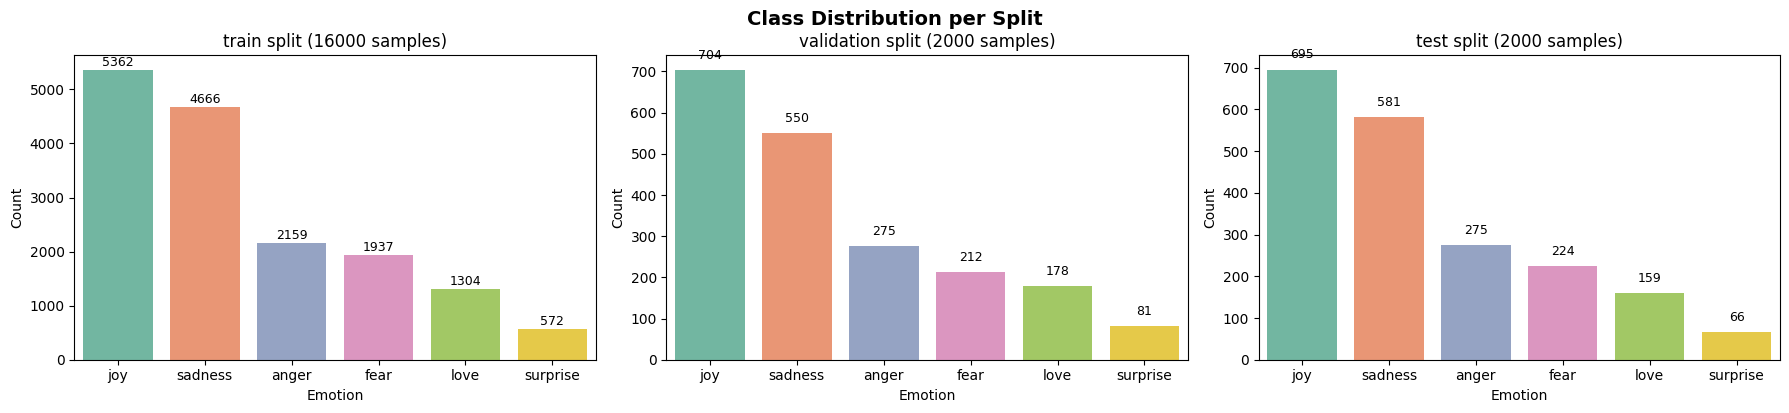

In [29]:
# Class distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, split in zip(axes, ["train", "validation", "test"]):
    df = dataset[split].to_pandas()
    counts = df["label"].map(id2label).value_counts()
    sns.barplot(x=counts.index, y=counts.values, palette="Set2", ax=ax)
    ax.set_title(f"{split} split ({len(df)} samples)")
    ax.set_xlabel("Emotion")
    ax.set_ylabel("Count")
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 20,
                int(bar.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.suptitle("Class Distribution per Split", y=1.02, fontsize=14, fontweight="bold")
plt.show()

In [30]:
#sampeltext from each emotion
for emotion in df_train['emotion'].unique():
    sample = df_train[df_train['emotion'] == emotion]['text'].iloc[0]
    print(f'Emotion : {emotion}')
    print(sample)
    print('-' * 50)

Emotion : sadness
i didnt feel humiliated
--------------------------------------------------
Emotion : anger
im grabbing a minute to post i feel greedy wrong
--------------------------------------------------
Emotion : love
i am ever feeling nostalgic about the fireplace i will know that it is still on the property
--------------------------------------------------
Emotion : surprise
ive been taking or milligrams or times recommended amount and ive fallen asleep a lot faster but i also feel like so funny
--------------------------------------------------
Emotion : fear
i feel as confused about life as a teenager or as jaded as a year old man
--------------------------------------------------
Emotion : joy
i have been with petronas for years i feel that petronas has performed well and made a huge profit
--------------------------------------------------


#4-Data Preprocessing

In [31]:
df_train

,text,label,emotion,length
0,i didnt feel humiliated,0,sadness,23
1,i can go from feeling so hopeless to so damned...,0,sadness,108
2,im grabbing a minute to post i feel greedy wrong,3,anger,48
3,i am ever feeling nostalgic about the fireplac...,2,love,92
4,i am feeling grouchy,3,anger,20
...,...,...,...,...
15995,i just had a very brief time in the beanbag an...,0,sadness,101
15996,i am now turning and i feel pathetic that i am...,0,sadness,102
15997,i feel strong and good overall,1,joy,30
15998,i feel like this was such a rude comment and i...,3,anger,59


In [32]:
# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Cleaning function
def clean_text(text):
    text = re.sub(r"[^a-zA-Z]", " ", text)
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = word_tokenize(text)
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)

# Apply to DataFrame
df_train['cleaned_text'] = df_train['text'].astype(str).apply(clean_text)

In [33]:
df_train

,text,label,emotion,length,cleaned_text
0,i didnt feel humiliated,0,sadness,23,didnt feel humiliated
1,i can go from feeling so hopeless to so damned...,0,sadness,108,go feeling hopeless damned hopeful around some...
2,im grabbing a minute to post i feel greedy wrong,3,anger,48,im grabbing minute post feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,2,love,92,ever feeling nostalgic fireplace know still pr...
4,i am feeling grouchy,3,anger,20,feeling grouchy
...,...,...,...,...,...
15995,i just had a very brief time in the beanbag an...,0,sadness,101,brief time beanbag said anna feel like beaten
15996,i am now turning and i feel pathetic that i am...,0,sadness,102,turning feel pathetic still waiting table subb...
15997,i feel strong and good overall,1,joy,30,feel strong good overall
15998,i feel like this was such a rude comment and i...,3,anger,59,feel like rude comment im glad


#5-Applying machine learning classifier

In [34]:
# ML packages
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [35]:
df2=df_train.copy()
df2

,text,label,emotion,length,cleaned_text
0,i didnt feel humiliated,0,sadness,23,didnt feel humiliated
1,i can go from feeling so hopeless to so damned...,0,sadness,108,go feeling hopeless damned hopeful around some...
2,im grabbing a minute to post i feel greedy wrong,3,anger,48,im grabbing minute post feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,2,love,92,ever feeling nostalgic fireplace know still pr...
4,i am feeling grouchy,3,anger,20,feeling grouchy
...,...,...,...,...,...
15995,i just had a very brief time in the beanbag an...,0,sadness,101,brief time beanbag said anna feel like beaten
15996,i am now turning and i feel pathetic that i am...,0,sadness,102,turning feel pathetic still waiting table subb...
15997,i feel strong and good overall,1,joy,30,feel strong good overall
15998,i feel like this was such a rude comment and i...,3,anger,59,feel like rude comment im glad


In [36]:
X = df_train['cleaned_text']
y = df_train['label']

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [38]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 3),
    stop_words='english',
    lowercase=True,
    strip_accents='unicode',
    sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [39]:
#Define the 6 classifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import SGDClassifier

SEED = 42
classifiers = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "Support Vector Machine": SVC(),
    "SGD Classifier (SVM alternative)": SGDClassifier(loss="hinge", max_iter=3000, tol=1e-3),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=7, metric="cosine"),
}

print("Classifiers defined:", list(classifiers.keys()))

Classifiers defined: ['Multinomial Naive Bayes', 'Logistic Regression', 'Random Forest', 'Support Vector Machine', 'SGD Classifier (SVM alternative)', 'K-Nearest Neighbors']


In [40]:
#Train & evaluate all 6 classifiers
import time
from sklearn.metrics import accuracy_score, f1_score, classification_report
ml_results = {}
for name, clf in  classifiers.items():
    t0 = time.time()
    clf.fit(X_train_tfidf, y_train)
    train_time = time.time() - t0
    y_pred_test = clf.predict(X_test_tfidf)
    test_acc = accuracy_score(y_test, y_pred_test)
    test_f1  = f1_score(y_test, y_pred_test, average="weighted")

    ml_results[name] = {
        "test_acc":  test_acc,
        "test_f1":   test_f1,
        "train_sec": train_time,
        "clf":       clf,
        "y_pred_test": y_pred_test,
    }

    print(f"[{name:30s}]  Test Acc: {test_acc:.4f}  Test F1: {test_f1:.4f}  ({train_time:.1f}s)")

[Multinomial Naive Bayes       ]  Test Acc: 0.7937  Test F1: 0.7679  (0.0s)
[Logistic Regression           ]  Test Acc: 0.8841  Test F1: 0.8797  (5.1s)
[Random Forest                 ]  Test Acc: 0.8822  Test F1: 0.8819  (21.6s)
[Support Vector Machine        ]  Test Acc: 0.8853  Test F1: 0.8815  (48.2s)
[SGD Classifier (SVM alternative)]  Test Acc: 0.9044  Test F1: 0.9031  (0.1s)
[K-Nearest Neighbors           ]  Test Acc: 0.7581  Test F1: 0.7513  (0.0s)


Models evaluations

In [41]:
# Leaderboard table
import pandas as pd

rows = []
for name, r in ml_results.items():
    rows.append({
        "Model":          name,
        "Test Acc":       f"{r['test_acc']:.4f}",
        "Test F1 (W)":    f"{r['test_f1']:.4f}",
        "Train Time (s)": f"{r['train_sec']:.1f}",
        "Test_Preds":     r["y_pred_test"]
    })

df_ml = pd.DataFrame(rows).sort_values("Test F1 (W)", ascending=False).reset_index(drop=True)
df_ml.index += 1
print(df_ml.to_string())

                              Model Test Acc Test F1 (W) Train Time (s)                                                                                                                                                                                                                                                                                                         Test_Preds
1  SGD Classifier (SVM alternative)   0.9044      0.9031            0.1  [0, 1, 0, 1, 0, 1, 4, 3, 2, 4, 4, 3, 4, 1, 0, 4, 3, 1, 2, 5, 3, 0, 0, 1, 0, 2, 1, 0, 0, 1, 1, 1, 0, 1, 2, 0, 0, 4, 1, 2, 1, 3, 1, 1, 4, 0, 1, 1, 0, 0, 3, 4, 1, 1, 0, 0, 1, 1, 0, 0, 2, 1, 1, 1, 3, 1, 0, 3, 0, 1, 0, 0, 0, 1, 0, 0, 3, 1, 4, 4, 4, 1, 3, 0, 1, 0, 4, 0, 1, 2, 2, 2, 1, 1, 1, 0, 4, 0, 2, 3, ...]
2                     Random Forest   0.8822      0.8819           21.6  [0, 1, 0, 1, 0, 1, 4, 3, 2, 4, 4, 3, 4, 1, 0, 4, 3, 1, 2, 0, 3, 1, 0, 1, 0, 2, 1, 0, 0, 1, 0, 1, 0, 1, 2, 0, 0, 4, 1, 2, 1, 3, 1, 1, 4, 0, 1, 1, 0, 0, 3, 4, 1, 1, 0, 0, 

/tmp/ipykernel_4943/2482500827.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=30, ha="right")
/tmp/ipykernel_4943/2482500827.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=30, ha="right")


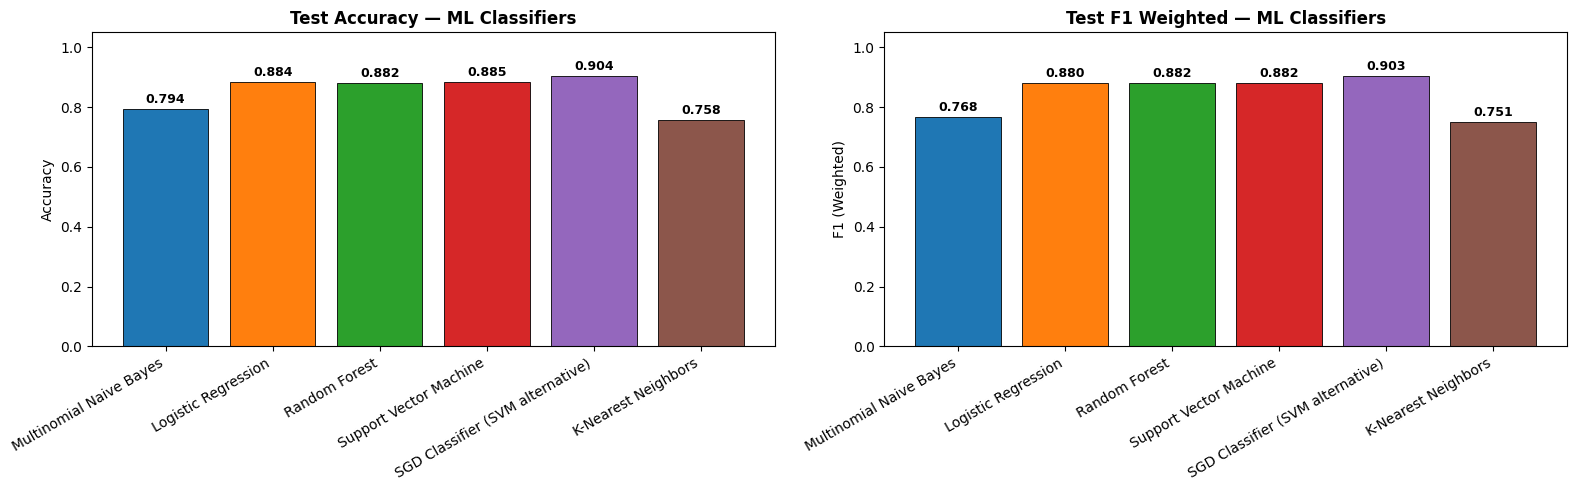

In [42]:
# Bar-chart comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

names  = list(ml_results.keys())
accs   = [ml_results[n]["test_acc"] for n in names]
f1s    = [ml_results[n]["test_f1"]  for n in names]

palette = sns.color_palette("tab10", len(names))

for ax, values, title, ylabel in [
    (axes[0], accs, "Test Accuracy — ML Classifiers",       "Accuracy"),
    (axes[1], f1s,  "Test F1 Weighted — ML Classifiers",    "F1 (Weighted)"),
]:
    bars = ax.bar(names, values, color=palette, edgecolor="black", linewidth=0.6)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight="bold")
    ax.set_xticklabels(names, rotation=30, ha="right")
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()


In [43]:
# Per-class report for best ML model
best_ml_name = max(ml_results, key=lambda n: ml_results[n]["test_f1"])
best_ml_pred = ml_results[best_ml_name]["y_pred_test"]

print(f"Best ML model: {best_ml_name}")
print()
print("=== Classification Report ===")
print(classification_report(y_test, best_ml_pred, target_names=LABEL_NAMES, digits=4))


Best ML model: SGD Classifier (SVM alternative)

=== Classification Report ===
              precision    recall  f1-score   support

     sadness     0.9297    0.9463    0.9379       950
         joy     0.8969    0.9484    0.9219      1027
        love     0.8750    0.7624    0.8148       303
       anger     0.9011    0.8929    0.8970       439
        fear     0.8877    0.8640    0.8757       375
    surprise     0.8916    0.6981    0.7831       106

    accuracy                         0.9044      3200
   macro avg     0.8970    0.8520    0.8717      3200
weighted avg     0.9039    0.9044    0.9031      3200



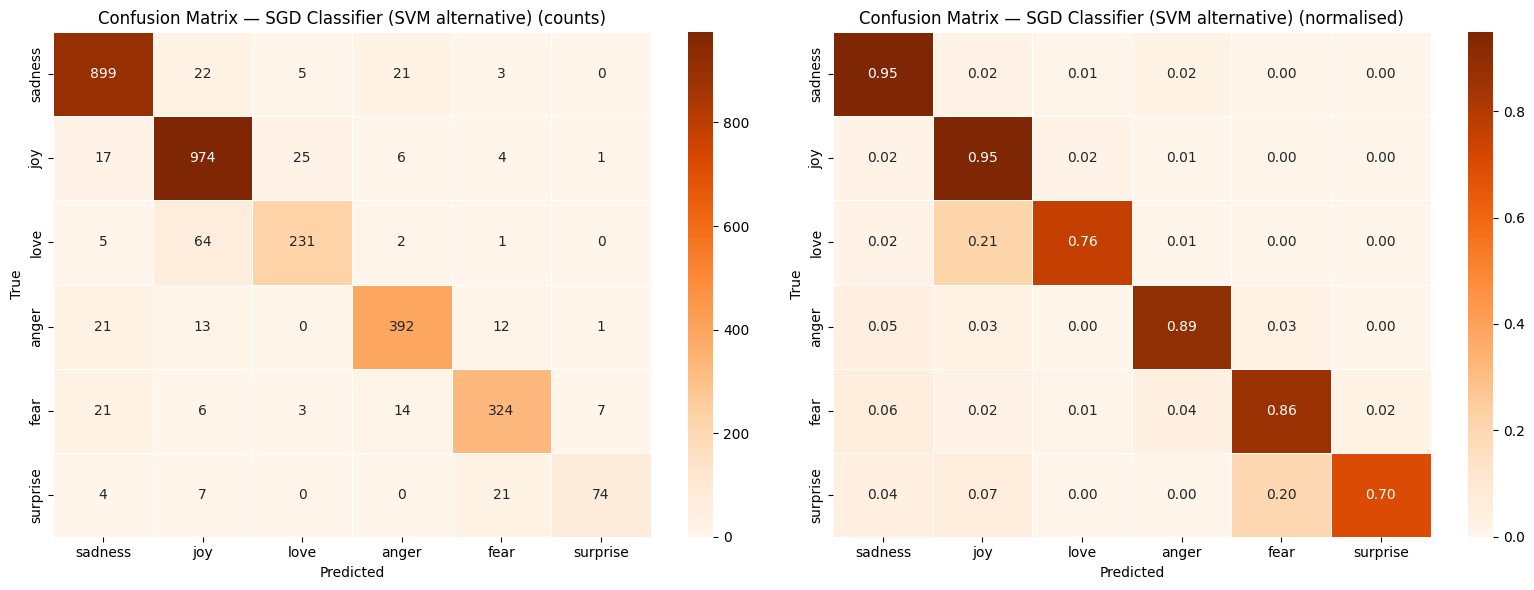

In [44]:
# Confusion matrix for best ML model
cm_ml      = confusion_matrix(y_test, best_ml_pred)
cm_ml_norm = cm_ml.astype(float) / cm_ml.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, data, fmt, title in zip(
    axes,
    [cm_ml, cm_ml_norm],
    ["d", ".2f"],
    [f"Confusion Matrix — {best_ml_name} (counts)",
     f"Confusion Matrix — {best_ml_name} (normalised)"],
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap="Oranges",
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
                ax=ax, linewidths=0.5)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
plt.tight_layout()
plt.show()

Predictive System (Machine Learning classfire)

In [45]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier

# Prediction Function
def predict_emotion(input_text, model):
    cleaned_text = clean_text(input_text)
    input_vectorized = tfidf_vectorizer.transform([cleaned_text])
    predicted_label = model.predict(input_vectorized)[0]
    predicted_emotion = id2label[predicted_label]
    return predicted_emotion, predicted_label


# Models
models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=2000,
            C=5.0,
            solver="lbfgs",
            random_state=SEED
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            n_jobs=-1,
            random_state=SEED
        ),
    "SVM":
        SGDClassifier(
            loss="hinge",
            max_iter=3000,
            tol=1e-3,
            random_state=SEED
        ),
    "Gradient Boosting":
        GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=5,
            random_state=SEED
        ),
    "Multinomial Naive Bayes":
        MultinomialNB(
            alpha=0.1
        ),
    "K-Nearest Neighbors":
        KNeighborsClassifier(
            n_neighbors=7,
            metric="cosine",
            n_jobs=-1
        ),
}
# Train Models
for name, clf in models.items():

    print(f"Training {name}...")

    clf.fit(X_train_tfidf, y_train)

print("\nAll models trained successfully!\n")


# Test Sentences
sentences = [
    "i didnt feel humiliated",
    "i feel strong and good overall",
    "im grabbing a minute to post i feel greedy wrong",
    "He was speechless when he found out he was accepted to this new job",
    "This is outrageous, how can you talk like that?",
    "I feel like im all alone in this world",
    "He is really sweet and caring",
    "You made me very crazy",
    "i am ever feeling nostalgic about the fireplace i will know that it is still on the property",
    "i am feeling grouchy",
    "He hates you"
]


# Select Model
selected_model = models["SVM"]
# Predictions
for sentence in sentences:
    pred_emotion, label = predict_emotion(sentence, selected_model)
    print(f"Text       : {sentence}")
    print(f"Prediction : {pred_emotion}")
    print(f"Label      : {label}")
    print("=" * 60)

Training Logistic Regression...
Training Random Forest...
Training SVM...
Training Gradient Boosting...
Training Multinomial Naive Bayes...
Training K-Nearest Neighbors...

All models trained successfully!

Text       : i didnt feel humiliated
Prediction : sadness
Label      : 0
Text       : i feel strong and good overall
Prediction : joy
Label      : 1
Text       : im grabbing a minute to post i feel greedy wrong
Prediction : anger
Label      : 3
Text       : He was speechless when he found out he was accepted to this new job
Prediction : joy
Label      : 1
Text       : This is outrageous, how can you talk like that?
Prediction : joy
Label      : 1
Text       : I feel like im all alone in this world
Prediction : joy
Label      : 1
Text       : He is really sweet and caring
Prediction : love
Label      : 2
Text       : You made me very crazy
Prediction : sadness
Label      : 0
Text       : i am ever feeling nostalgic about the fireplace i will know that it is still on the property
Pred

In [46]:
import pickle


# Save Your Models


pickle.dump(
    models["Logistic Regression"],
    open("logistic_regression.pkl", "wb")
)

pickle.dump(
    models["Random Forest"],
    open("random_forest.pkl", "wb")
)

pickle.dump(
    models["SVM"],
    open("svm_model.pkl", "wb")
)

pickle.dump(
    models["Gradient Boosting"],
    open("gradient_boosting.pkl", "wb")
)

pickle.dump(
    models["Multinomial Naive Bayes"],
    open("multinomial_nb.pkl", "wb")
)

pickle.dump(
    models["K-Nearest Neighbors"],
    open("knn_model.pkl", "wb")
)

# Save TF-IDF Vectorizer

pickle.dump(
    tfidf_vectorizer,
    open("tfidf_vectorizer.pkl", "wb")
)

# Save Label Encoder (or id2label mapping)

pickle.dump(
    id2label,
    open("id2label.pkl", "wb") # Changed from lb to id2label
)
print("All models saved successfully!")

All models saved successfully!


# 6-Applying DeepLearning (LSTM)

In [47]:
!pip install -q transformers datasets evaluate accelerate seaborn scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.9 MB/s eta 0:00:00


In [48]:
# DL packages
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, Bidirectional, Dense, Dropout,
    SpatialDropout1D, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)

print("All Deep LSTM packages imported successfully!")

All Deep LSTM packages imported successfully!


In [49]:
# Text cleaning function
def text_cleaning(df2, column, vocab_size, max_len):
    corpus = []

    for text in df2[column]:
        text = re.sub(r"[^a-zA-Z]", " ", str(text))
        text = text.lower()
        words = word_tokenize(text)
        words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
        cleaned_text = " ".join(words)
        corpus.append(cleaned_text)

    # One-hot encode and pad
    one_hot_word = [one_hot(input_text=text, n=vocab_size) for text in corpus]
    pad = pad_sequences(sequences=one_hot_word, maxlen=max_len, padding='pre')
    return pad

Model Buliding and training

In [50]:
# Hyperparameters
VOCAB_SIZE  = 20000
MAX_LEN     = 100
EMBED_DIM   = 128
LSTM_UNITS  = 128
DROPOUT     = 0.3
BATCH_SIZE  = 64
EPOCHS      = 20
SEED        = 42

np.random.seed(SEED)
print("Hyperparameters set.")

Hyperparameters set.


In [51]:
# Prepare train / val / test splits
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('punkt_tab', quiet=True)
lemmatizer = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))
def clean_for_lstm(text):
    text  = re.sub(r"[^a-zA-Z]", " ", str(text))
    text  = text.lower()
    words = word_tokenize(text)
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(words)

# Apply cleaning to each split
train_texts  = [clean_for_lstm(t) for t in dataset["train"]["text"]]
val_texts    = [clean_for_lstm(t) for t in dataset["validation"]["text"]]
test_texts   = [clean_for_lstm(t) for t in dataset["test"]["text"]]

train_labels = dataset["train"]["label"]
val_labels   = dataset["validation"]["label"]
test_labels  = dataset["test"]["label"]

print(f"Train: {len(train_texts)} | Val: {len(val_texts)} | Test: {len(test_texts)}")


Train: 16000 | Val: 2000 | Test: 2000


In [52]:
# Tokenise & Pad
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(train_texts),
                             maxlen=MAX_LEN, padding='pre', truncating='post')
X_val_seq   = pad_sequences(tokenizer.texts_to_sequences(val_texts),
                             maxlen=MAX_LEN, padding='pre', truncating='post')
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(test_texts),
                             maxlen=MAX_LEN, padding='pre', truncating='post')

NUM_CLASSES = len(LABEL_NAMES)
y_train_cat = to_categorical(train_labels, num_classes=NUM_CLASSES)
y_val_cat   = to_categorical(val_labels,   num_classes=NUM_CLASSES)
y_test_cat  = to_categorical(test_labels,  num_classes=NUM_CLASSES)

print(f"X_train shape : {X_train_seq.shape}")
print(f"X_val   shape : {X_val_seq.shape}")
print(f"X_test  shape : {X_test_seq.shape}")
print(f"Classes       : {NUM_CLASSES} → {LABEL_NAMES}")


X_train shape : (16000, 100)
X_val   shape : (2000, 100)
X_test  shape : (2000, 100)
Classes       : 6 → ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


In [53]:
# Build and compile the model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout,
    BatchNormalization,
    SpatialDropout1D
)
from tensorflow.keras.callbacks import EarlyStopping
# Build Model
model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBED_DIM,
        input_length=MAX_LEN
    ),

    SpatialDropout1D(0.3),
    # Single LSTM Layer
    LSTM(
        LSTM_UNITS,
        dropout=0.3,
        recurrent_dropout=0.2
    ),

    BatchNormalization(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(NUM_CLASSES, activation='softmax')

])
# Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
# Early Stopping
callback = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)
# Train
history = model.fit(
    X_train_seq,
    y_train_cat,
    epochs=10,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_seq, y_val_cat),
    callbacks=[callback],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 102s 383ms/step - accuracy: 0.5270 - loss: 1.2684 - val_accuracy: 0.6325 - val_loss: 1.3787
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 135s 358ms/step - accuracy: 0.8314 - loss: 0.5227 - val_accuracy: 0.8530 - val_loss: 0.5585
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 141s 354ms/step - accuracy: 0.9152 - loss: 0.2709 - val_accuracy: 0.8745 - val_loss: 0.3826
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 91s 363ms/step - accuracy: 0.9407 - loss: 0.1837 - val_accuracy: 0.8855 - val_loss: 0.3950
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 92s 369ms/step - accuracy: 0.9541 - loss: 0.1411 - val_accuracy: 0.8915 - val_loss: 0.3626
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 90s 362ms/step - accuracy: 0.9614 - loss: 0.1149 - val_accuracy: 0.9020 - val_loss: 0.3584
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 141s 357ms/step - accuracy: 0.9654 - loss: 0.0948 - val_accuracy: 0.9040 - val_loss: 0.3366
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 92s 370ms/step - accuracy: 0.9697 - los

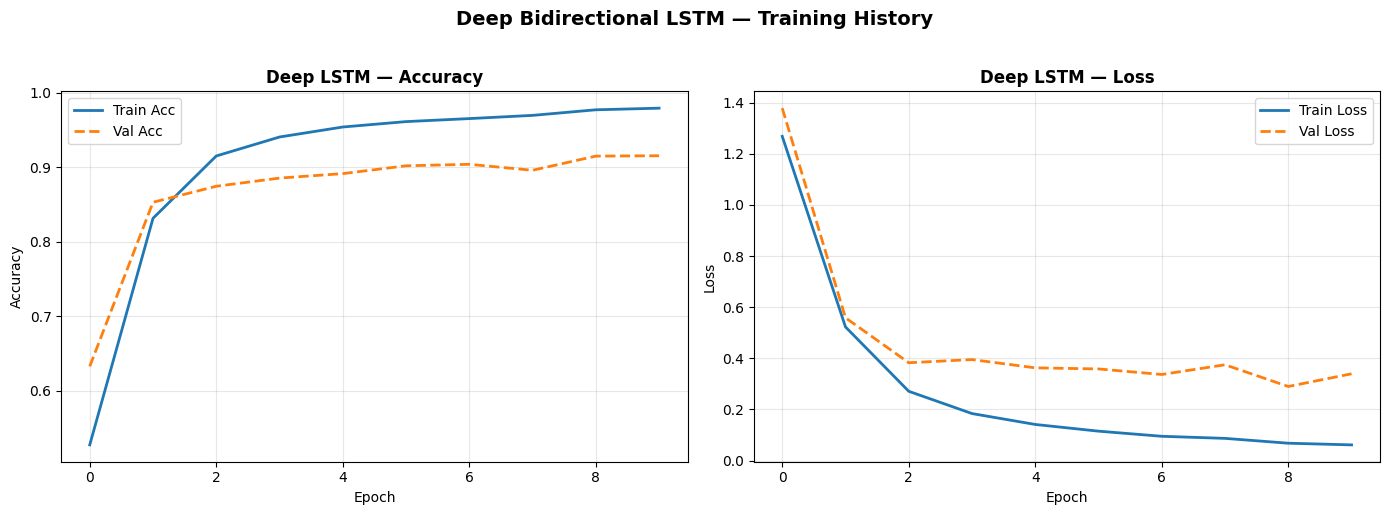

In [54]:
# Training Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Acc',  linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Acc',    linewidth=2, linestyle='--')
axes[0].set_title('Deep LSTM — Accuracy',    fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss',   linewidth=2, linestyle='--')
axes[1].set_title('Deep LSTM — Loss', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Deep Bidirectional LSTM — Training History',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [55]:
# Evaluation on Test Set
loss_test, acc_test = model.evaluate(X_test_seq, y_test_cat, verbose=0)
y_pred_prob  = model.predict(X_test_seq, verbose=0)
y_pred_class = np.argmax(y_pred_prob, axis=1)
y_true_class = np.array(test_labels)
f1_weighted  = f1_score(y_true_class, y_pred_class, average='weighted')
f1_macro     = f1_score(y_true_class, y_pred_class, average='macro')
print("=" * 55)
print("         Deep Bidirectional LSTM — Test Results")
print("=" * 55)
print(f"  Test Loss        : {loss_test:.4f}")
print(f"  Test Accuracy    : {acc_test:.4f}")
print(f"  F1 Weighted      : {f1_weighted:.4f}")
print(f"  F1 Macro         : {f1_macro:.4f}")
print("=" * 55)
print()
print("=== Classification Report ===")
print(classification_report(y_true_class, y_pred_class,
                            target_names=LABEL_NAMES, digits=4))

         Deep Bidirectional LSTM — Test Results
  Test Loss        : 0.2816
  Test Accuracy    : 0.9095
  F1 Weighted      : 0.9098
  F1 Macro         : 0.8743

=== Classification Report ===
              precision    recall  f1-score   support

     sadness     0.9549    0.9484    0.9516       581
         joy     0.9264    0.9237    0.9251       695
        love     0.7557    0.8365    0.7940       159
       anger     0.8964    0.9127    0.9045       275
        fear     0.8972    0.8571    0.8767       224
    surprise     0.8333    0.7576    0.7937        66

    accuracy                         0.9095      2000
   macro avg     0.8773    0.8727    0.8743      2000
weighted avg     0.9107    0.9095    0.9098      2000



In [56]:
# Predictive System — Deep LSTM
EMOJI_MAP = {
    'sadness': '😔', 'joy': '😄', 'love': '❤️',
    'anger': '😡', 'fear': '😨', 'surprise': '😲'
}
def predict_emotion_lstm(input_text, model=model,
                          tok=tokenizer, max_len=MAX_LEN):
    """
    Predict the emotion of a raw text string using the Deep LSTM model.

    Returns:
        emotion  (str)   – predicted emotion label
        label_id (int)   – numeric label
        confidence (float) – model confidence (max softmax probability)
        probs    (dict)  – probability for every class
    """
    cleaned  = clean_for_lstm(input_text)
    seq      = tokenizer.texts_to_sequences([cleaned])
    padded   = pad_sequences(seq, maxlen=max_len,
                             padding='pre', truncating='post')

    prob_vec    = model.predict(padded, verbose=0)[0]
    label_id    = int(np.argmax(prob_vec))
    emotion     = id2label[label_id]
    confidence  = float(prob_vec[label_id])
    all_probs   = {id2label[i]: float(prob_vec[i]) for i in range(len(prob_vec))}

    return emotion, label_id, confidence, all_probs


# Test on sample sentences
test_sentences = [
    "i didnt feel humiliated",
    "i feel strong and good overall",
    "im grabbing a minute to post i feel greedy wrong",
    "He was speechless when he found out he was accepted to this new job",
    "This is outrageous, how can you talk like that?",
    "I feel like im all alone in this world",
    "He is really sweet and caring",
    "You made me very crazy",
    "i am ever feeling nostalgic about the fireplace",
    "i am feeling grouchy",
    "He hates you",
]

print("=" * 65)
print("          Deep BiLSTM — Emotion Prediction Results")
print("=" * 65)
for sentence in test_sentences:
    emotion, lid, conf, probs = predict_emotion_lstm(sentence)
    emoji = EMOJI_MAP.get(emotion, '')
    print(f"Text       : {sentence}")
    print(f"Prediction : {emotion.upper()} {emoji}  (confidence: {conf:.1%})")
    # Show top-3 probabilities
    top3 = sorted(probs.items(), key=lambda x: x[1], reverse=True)[:3]
    print(f"Top-3      : " + "  |  ".join(f"{e}: {p:.1%}" for e, p in top3))
    print("-" * 65)


          Deep BiLSTM — Emotion Prediction Results
Text       : i didnt feel humiliated
Prediction : SADNESS 😔  (confidence: 100.0%)
Top-3      : sadness: 100.0%  |  anger: 0.0%  |  joy: 0.0%
-----------------------------------------------------------------
Text       : i feel strong and good overall
Prediction : JOY 😄  (confidence: 100.0%)
Top-3      : joy: 100.0%  |  love: 0.0%  |  anger: 0.0%
-----------------------------------------------------------------
Text       : im grabbing a minute to post i feel greedy wrong
Prediction : ANGER 😡  (confidence: 100.0%)
Top-3      : anger: 100.0%  |  fear: 0.0%  |  sadness: 0.0%
-----------------------------------------------------------------
Text       : He was speechless when he found out he was accepted to this new job
Prediction : LOVE ❤️  (confidence: 57.7%)
Top-3      : love: 57.7%  |  joy: 39.9%  |  sadness: 0.9%
-----------------------------------------------------------------
Text       : This is outrageous, how can you talk like th

In [57]:
# Save Deep LSTM Model
import pickle, os
# Save Keras model (full model with weights)
model.save("deep_bilstm_emotion.keras")
# Save the tokenizer so we can reload it for inference
with open("lstm_tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)
# Save id2label mapping (if not already saved)
with open("id2label.pkl", "wb") as f:
    pickle.dump(id2label, f)

print(" Model saved  →  deep_lstm_emotion.keras")
print("Tokenizer saved  →  lstm_tokenizer.pkl")
print(" id2label saved   →  id2label.pkl")

 Model saved  →  deep_lstm_emotion.keras
Tokenizer saved  →  lstm_tokenizer.pkl
 id2label saved   →  id2label.pkl
